# 最急降下法

### データ準備

In [164]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from sklearn.linear_model import LinearRegression

<AxesSubplot:xlabel='space', ylabel='rent'>

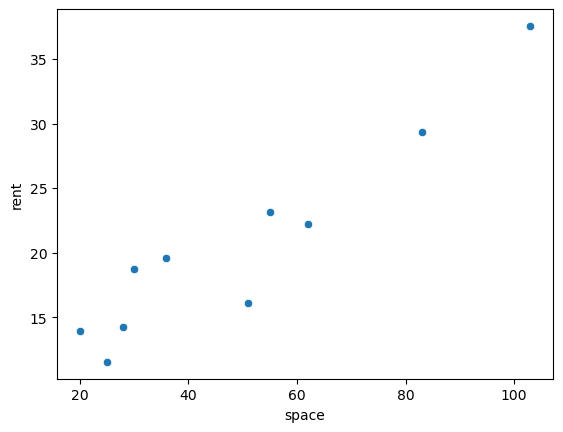

In [10]:
df = pd.read_csv('sample_data.csv')
sns.scatterplot(x='space', y='rent', data=df)

### 損失関数の定義

In [82]:
x = df['space'].values
y = df['rent'].values

def cost_func(theta_0, theta_1, x, y):
    return np.mean(np.square(y-(theta_0 + theta_1*x)))

### 損失関数の可視化

In [83]:
x = np.array([1, 2, 3, 4])
y = np.array([10, 20, 30, 40])
X, Y = np.meshgrid(x, y)
z =[x*y for x, y in product(x, y)] #productの順番に注意
Z = np.array(z).reshape(4, 4)

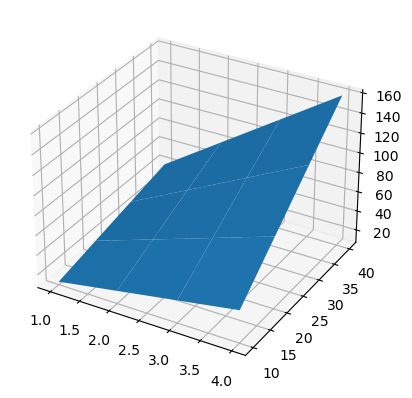

In [84]:
ax = plt.axes(projection='3d')
ax.plot_surface(X=X, Y=Y, Z=Z)

In [106]:
x = df['space'].values
y = df['rent'].values

#軸の範囲とメモリの数を定義
n0 = n1 = 300
min_0 = -20
max_0 = 20
min_1 = -1
max_1 = 1

#軸の値のリストを作成
theta_0 = np.linspace(min_0, max_0, n0)
theta_1 = np.linspace(min_1, max_1, n1)

#それぞれのΘの軸の総組み合わせの損失関数の値を計算
theta_0_ax, theta_1_ax = np.meshgrid(theta_0, theta_1)
z = [cost_func(param[0], param[1], x=x, y=y) for param in list(product(theta_0, theta_1))]
Z = np.array(z).reshape(n0, n1)

Text(0.5, 0, 'cost_func')

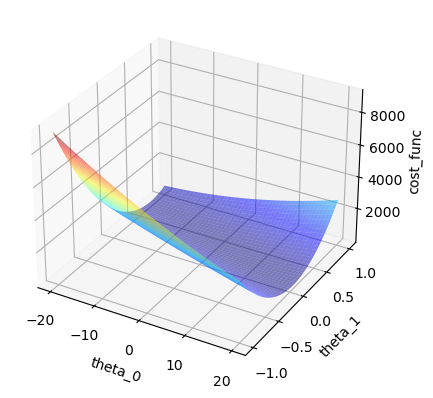

In [111]:
#3Dで描画
ax = plt.axes(projection='3d')
ax.plot_surface(theta_0_ax.T, theta_1_ax.T, Z, cmap='jet', alpha=0.5)
ax.set_xlabel("theta_0", size = 10)
ax.set_ylabel("theta_1", size = 10)
ax.set_zlabel("cost_func", size = 10)

## 最急降下法

In [128]:
#np.random.seed(0)
#theta_0_init = np.random.uniform(min_0, max_0)
#theta_1_init = np.random.uniform(min_1, max_1)

theta_0_init = -5
theta_1_init = -0.5

def update_theta0(theta_0, theta_1, x, y, alpha=0.05):
    return theta_0 -alpha * 2 * np.mean(((theta_0 + theta_1*x) - y))

def update_theta1(theta_0, theta_1, x, y, alpha=0.05):
    return theta_1 -alpha * 2 * np.mean(((theta_0 + theta_1*x) - y) * x)

epochs = 100000
alpha = 0.00005

#初期化
theta_0_hist = []
theta_1_hist = []

theta_0_hist.append(theta_0_init)
theta_1_hist.append(theta_1_init)

for _ in range(epochs):
    updated_theta_0 = update_theta0(theta_0_hist[-1], theta_1_hist[-1], x=x, y=y, alpha=alpha)
    updated_theta_1 = update_theta1(theta_0_hist[-1], theta_1_hist[-1], x=x, y=y, alpha=alpha)
    theta_0_hist.append(updated_theta_0)
    theta_1_hist.append(updated_theta_1)

In [159]:
theta_0_hist[-1]

5.692313583745944

###　結果の描画

In [133]:
cost_hist = [cost_func(*param, x=x, y=y) for param in zip(theta_0_hist, theta_1_hist)]

Text(0.5, 0, 'cost_func')

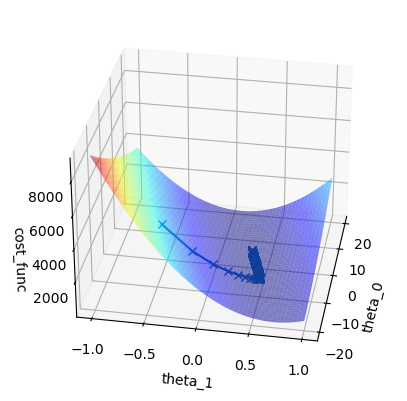

In [135]:
ax = plt.axes(projection='3d')
ax.plot(theta_0_hist, theta_1_hist, cost_hist, 'x-')
ax.plot_surface(theta_0_ax.T, theta_1_ax.T, Z, cmap='jet', alpha=0.5)
plt.gca().invert_xaxis()
ax.view_init(elev=30, azim=10)
ax.set_xlabel("theta_0", size = 10)
ax.set_ylabel("theta_1", size = 10)
ax.set_zlabel("cost_func", size = 10)

Text(0, 0.5, 'theta 0')

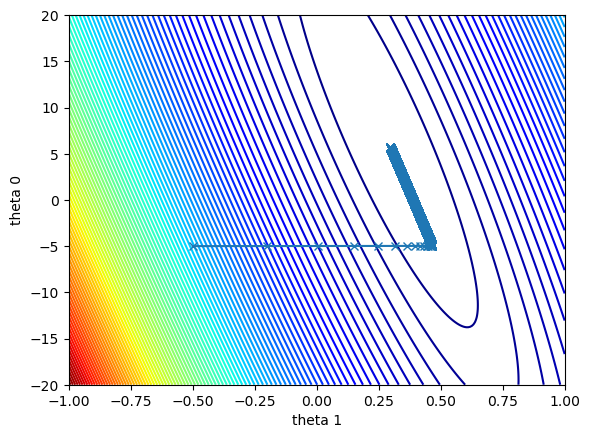

In [143]:
plt.contour(theta_1_ax.T, theta_0_ax.T, Z, 100, cmap='jet')
plt.plot(theta_1_hist, theta_0_hist, 'x-')
plt.xlabel('theta 1')
plt.ylabel('theta 0')

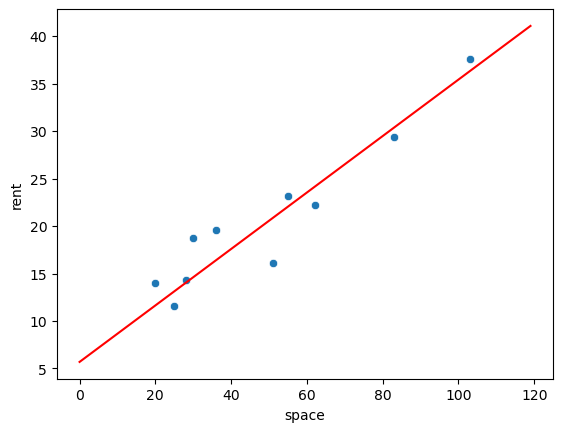

In [149]:
sns.scatterplot(x='space', y='rent', data=df)
x_values = np.arange(120)
y_value = theta_0_hist[-1] + theta_1_hist[-1]*x_values
plt.plot(x_values, y_value, '-', color='r')

### 正規方程式

####　行列Xを作る

In [157]:
X = np.vstack([np.ones(len(x)), x]).T

### 正規方程式の計算

In [161]:
best_theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y.T)

#### グラフに描画

Text(0, 0.5, 'theta 0')

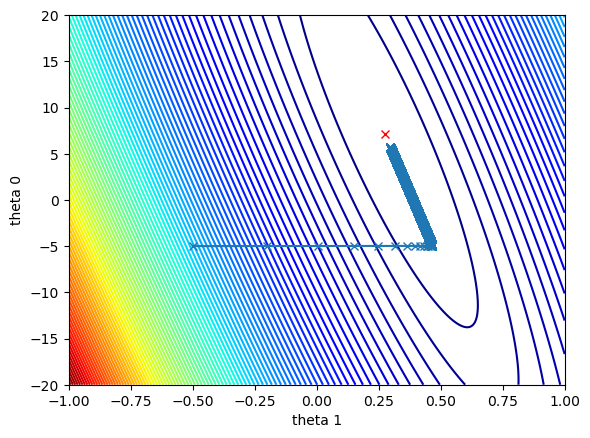

In [163]:
plt.contour(theta_1_ax.T, theta_0_ax.T, Z, 100, cmap='jet')
plt.plot(theta_1_hist, theta_0_hist, 'x-')
plt.plot(best_theta[1], best_theta[0], 'x', color='r')
plt.xlabel('theta 1')
plt.ylabel('theta 0')

# Scikit-learnで線形回帰

In [172]:
model = LinearRegression()

x = df['space'].values
y = df['rent'].values
X = x.reshape(10, 1)
model.fit(X, y)
model.predict(X)

array([12.59366469, 13.96802274, 14.79263756, 15.34238078, 16.99161044,
       21.11468458, 22.21417102, 24.13827229, 29.91057608, 35.40800827])

In [175]:
# coefficient係数
model.coef_

array([0.27487161])

In [176]:
#intercept切片
model.intercept_

7.0962324999088295